# Exploratory Data Analysis: Bivariate Analysis

The objective of this section is to explore and understand the relationships between pairs of variables in the student performance dataset. Bivariate analysis is conducted to identify correlations, trends, and differences between numerical and/or categorical features, revealing how one variable may influence or relate to another.

The analysis focuses on key combinations of variables, such as student grades, motivation, study habits, and demographics, to uncover patterns in performance and behavior. Visualizations including scatterplots, line charts, and boxplots are used to illustrate these relationships and highlight differences across groups or trends over time.
The datasets used in this analysis are:

- `ensia_cleaned_1Y_grouped_imputed.csv`
- `ensia_cleaned_2Y_grouped_imputed.csv`
- `ensia_cleaned_3Y_grouped_imputed.csv`


In [ ]:
# Importing requireed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
#reading data from csv files 
data_1y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_1Y_grouped_imputed.csv')
data_2y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_2Y_grouped_imputed.csv')
data_3y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_3Y_grouped_imputed.csv')
print("Data Loaded Successfully")
print("Data 1Y shape:", data_1y.shape)
data_1y.head()
print("Data 2Y shape:", data_2y.shape)
data_2y.head() 
print("Data 3Y shape:", data_3y.shape)
data_3y.head()

Data Loaded Successfully
Data 1Y shape: (210, 45)
Data 2Y shape: (101, 45)
Data 3Y shape: (12, 45)


,record_id,what is your gender,in which year of your studies are you currently enrolled,what was your bac specialty,how many hours per week do you spend studying personnal efforts,where do you prefer to study,you prefer to study,what learning methods do help you understand better,what types of resources do you use most,do you use a planer or a schedule in your revisions,...,3y average s2,3y average,3Y_math_avg,3Y_math_n,3Y_programming_avg,3Y_programming_n,3Y_other_avg,3Y_other_n,3Y_all_modules_avg,3Y_all_modules_n
0,45,Female,Fourth year,Technical maths,10-17,In your room (dorms),Alone,Lectures;Learning by practicing;Mind mapping a...,Books;Online tutorials;Online documents;YouTub...,Yes,...,13.0,12.0,2.750,4,2.714286,7,5.0,1,2.916667,12
1,78,Male,Fourth year,Technical maths,10-17,In your room (dorms),Alone,Mind mapping and visualization,Books;YouTube videos,Yes,...,11.0,10.0,3.125,0,3.071429,0,4.0,0,3.208333,0
2,80,Male,Fourth year,Technical maths,10-17,At home,In peer,Lectures;Learning by practicing;Project-based ...,Books;Online documents,No,...,13.0,13.0,3.500,4,3.428571,7,4.0,1,3.500000,12
3,84,Female,Fourth year,Mathematics,10-17,In your room (dorms),Alone,Learning by practicing;Project-based learning;...,Online tutorials;YouTube videos,Yes,...,10.0,10.0,3.125,0,3.071429,0,4.0,0,3.208333,0
4,86,Female,Fourth year,Mathematics,10-17,In your room (dorms),In peer,Learning by practicing;Mind mapping and visual...,Online documents;YouTube videos,Yes,...,11.0,10.0,3.125,0,3.071429,0,4.0,0,3.208333,0


# 1) Numerical-Numerical Data relationships 

### a. Yearly Average vs Motivation

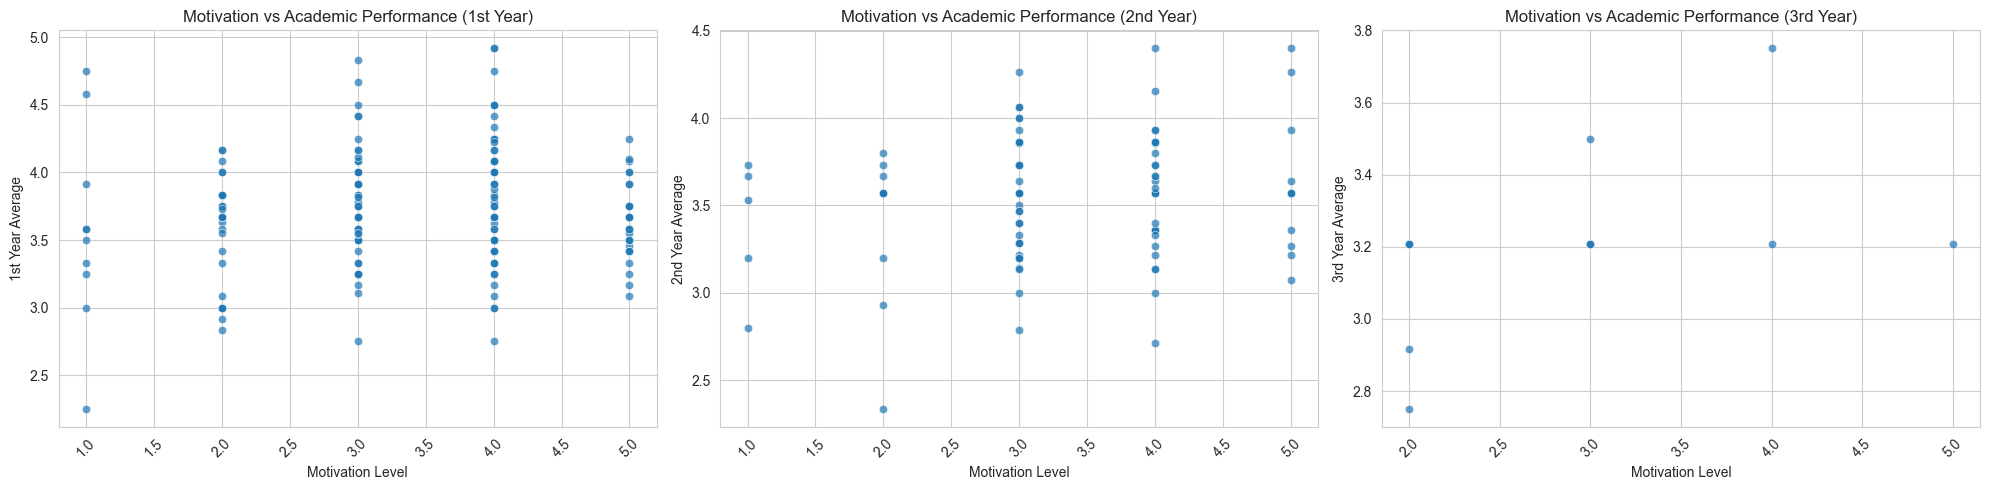

In [ ]:


sns.set_style('whitegrid')

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(20,5))

# Plot 1: 1 year average vs motivation scatter plot
sns.scatterplot(
    x=data_1y['your level of motivation for joining ensia'],
    y=data_1y['1Y_all_modules_avg'],
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Motivation vs Academic Performance (1st Year)')
axes[0].set_ylabel('1st Year Average')
axes[0].set_xlabel('Motivation Level')
axes[0].tick_params(axis='x', rotation=45)
plt.tight_layout()
# Plot 2: 2 year average vs motivation scatter plot
sns.scatterplot(
    x=data_2y['your level of motivation for joining ensia'],
    y=data_2y['2Y_all_modules_avg'],
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Motivation vs Academic Performance (2nd Year)')
axes[1].set_ylabel('2nd Year Average')
axes[1].set_xlabel('Motivation Level')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
# Plot 3: 3 year average vs motivation scatter plot
sns.scatterplot(
    x=data_3y['your level of motivation for joining ensia'],
    y=data_3y['3Y_all_modules_avg'],
    alpha=0.7,
    ax=axes[2]
)
axes[2].set_title('Motivation vs Academic Performance (3rd Year)')
axes[2].set_ylabel('3rd Year Average')
axes[2].set_xlabel('Motivation Level')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
performance_cols = ['1y average', '1Y_math_avg', '1Y_programming_avg', '1Y_other_avg']
print("\nPerformance Statistics:")
print(data_1y[performance_cols].describe())

# Convert sleep hours to numeric
sleep_mapping = {
    '4 hours or less': 4,
    '5-7 hours': 6,
    '8 hours or more': 8
}
data_1y['sleep_numeric'] = data_1y['how many hours do you sleep'].map(sleep_mapping)
data_2y['sleep_numeric'] = data_2y['how many hours do you sleep'].map(sleep_mapping)
data_3y['sleep_numeric'] = data_3y['how many hours do you sleep'].map(sleep_mapping)
print("\nSample size:", len(data_1y))
print("\n" + "=" * 80)




Performance Statistics:
       1y average  1Y_math_avg  1Y_programming_avg  1Y_other_avg
count  210.000000   210.000000          210.000000    210.000000
mean    13.042857     3.523889            3.644444      3.935397
std      1.614252     0.537013            0.552442      0.467018
min      9.000000     2.000000            2.000000      1.400000
25%     12.000000     3.200000            3.333333      3.750000
50%     13.000000     3.500000            3.666667      4.000000
75%     14.000000     3.800000            4.000000      4.200000
max     17.000000     5.000000            5.000000      5.000000

Sample size: 210



### b. Hours of Sleep vs Average 



ANALYSIS 1: SLEEP HOURS VS PERFORMANCE


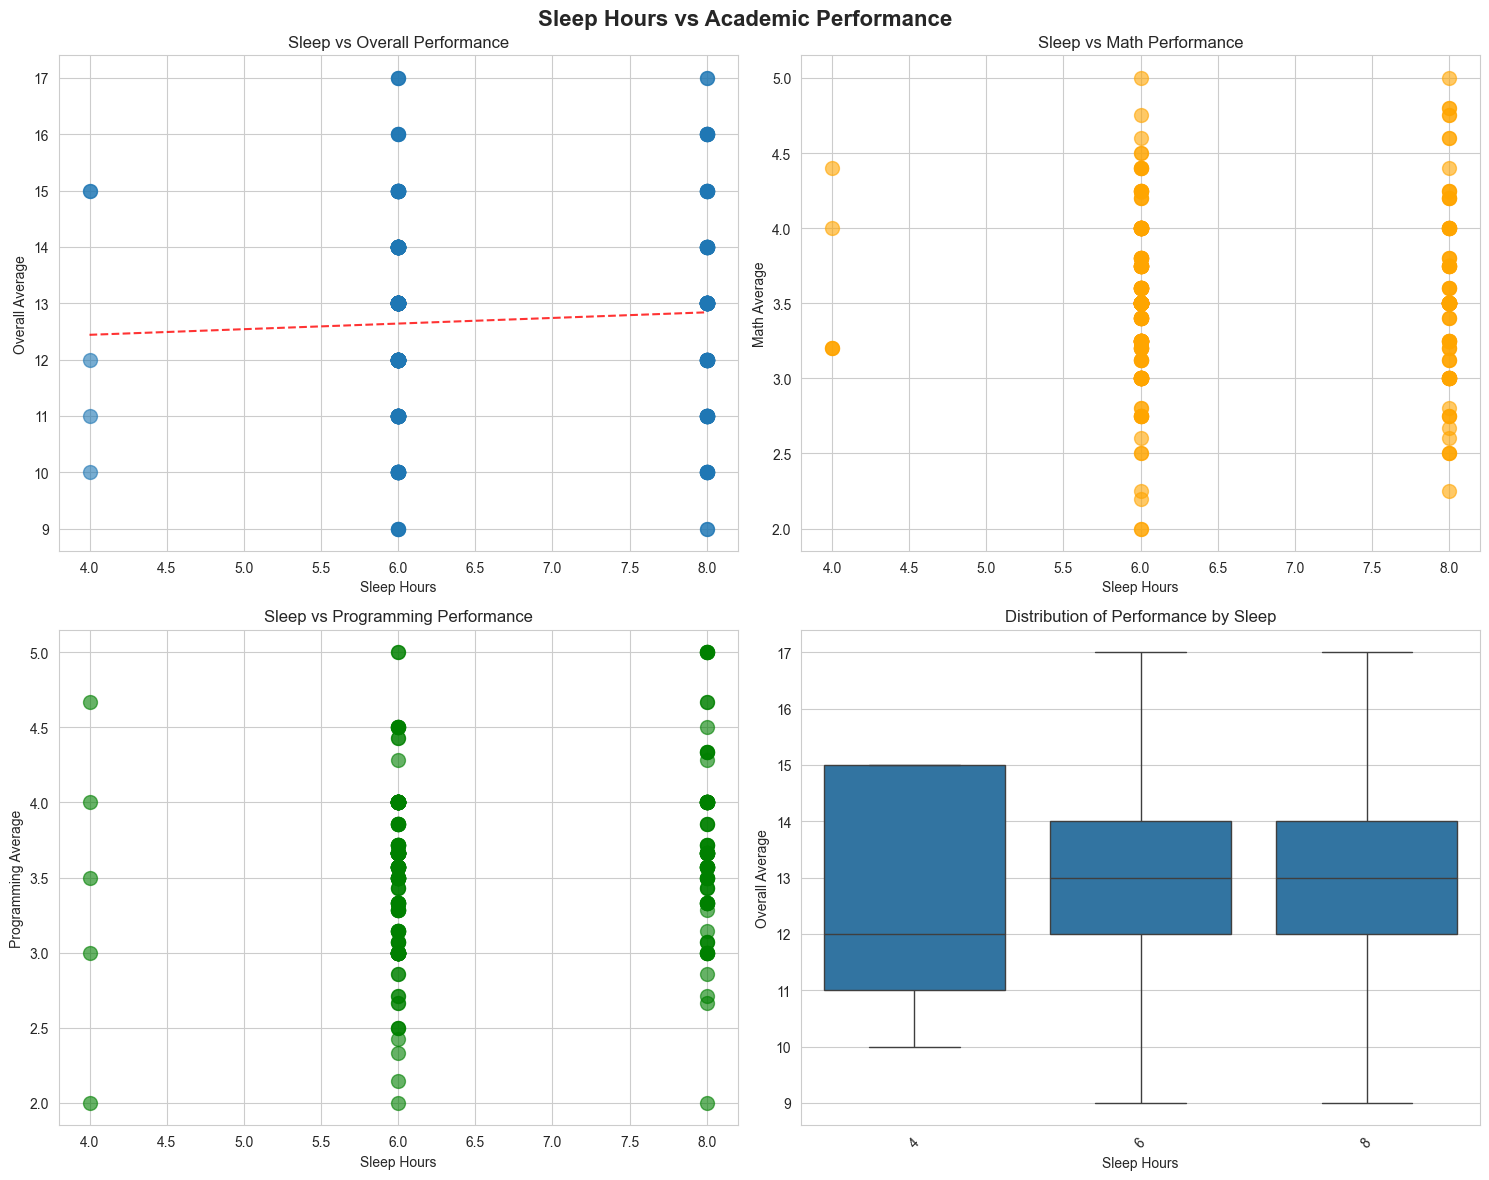

Rows: 323

Correlation between sleep and overall performance: 0.059
0.05887896854317071 0.29142637635931284


In [ ]:
print("\n\n" + "=" * 80)
print("ANALYSIS 1: SLEEP HOURS VS PERFORMANCE")
print("=" * 80)

data_1y_renamed = data_1y[['sleep_numeric', '1y average', '1Y_math_avg', '1Y_programming_avg']].copy()
data_1y_renamed.columns = ['sleep_numeric', 'overall_average', 'math_avg', 'programming_avg']

data_2y_renamed = data_2y[['sleep_numeric', '2y average', '2Y_math_avg', '2Y_programming_avg']].copy()
data_2y_renamed.columns = ['sleep_numeric', 'overall_average', 'math_avg', 'programming_avg']

data_3y_renamed = data_3y[['sleep_numeric', '3y average', '3Y_math_avg', '3Y_programming_avg']].copy()
data_3y_renamed.columns = ['sleep_numeric', 'overall_average', 'math_avg', 'programming_avg']

# Concatenate (stack rows)
data_sleep_perf = pd.concat([data_1y_renamed, data_2y_renamed, data_3y_renamed], ignore_index=True).dropna()


fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Sleep Hours vs Academic Performance', fontsize=16, fontweight='bold')

# Overall average
axes[0, 0].scatter(data_sleep_perf['sleep_numeric'], data_sleep_perf['overall_average'], alpha=0.6, s=100)
axes[0, 0].set_xlabel('Sleep Hours')
axes[0, 0].set_ylabel('Overall Average')
axes[0, 0].set_title('Sleep vs Overall Performance')
z = np.polyfit(data_sleep_perf['sleep_numeric'].dropna(), data_sleep_perf['overall_average'].dropna(), 1)
p = np.poly1d(z)
axes[0, 0].plot(data_sleep_perf['sleep_numeric'].dropna().sort_values(), 
                p(data_sleep_perf['sleep_numeric'].dropna().sort_values()), "r--", alpha=0.8)

# Math average
axes[0, 1].scatter(data_sleep_perf['sleep_numeric'], data_sleep_perf['math_avg'], alpha=0.6, s=100, color='orange')
axes[0, 1].set_xlabel('Sleep Hours')
axes[0, 1].set_ylabel('Math Average')
axes[0, 1].set_title('Sleep vs Math Performance')

# Programming average
axes[1, 0].scatter(data_sleep_perf['sleep_numeric'], data_sleep_perf['programming_avg'], alpha=0.6, s=100, color='green')
axes[1, 0].set_xlabel('Sleep Hours')
axes[1, 0].set_ylabel('Programming Average')
axes[1, 0].set_title('Sleep vs Programming Performance')

# Box plot summary
sns.boxplot(data=data_sleep_perf, x='sleep_numeric', y='overall_average', ax=axes[1, 1])
axes[1, 1].set_xlabel('Sleep Hours')
axes[1, 1].set_ylabel('Overall Average')
axes[1, 1].set_title('Distribution of Performance by Sleep')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Correlation statistics
corr = data_sleep_perf[['sleep_numeric', 'overall_average']].corr().iloc[0, 1]
print("Rows:", data_sleep_perf.shape[0])
print(f"\nCorrelation between sleep and overall performance: {corr:.3f}")
from scipy.stats import pearsonr

r, p = pearsonr(data_sleep_perf['sleep_numeric'], data_sleep_perf['overall_average'])
print(r, p)


### c. Math Average vs Programming average

MATH AVERAGE VS PROGRAMMING AVERAGE
Total students: 323

Math Average: Mean=3.51, Std=0.50
Programming Average: Mean=3.59, Std=0.51

Pearson Correlation: 0.623


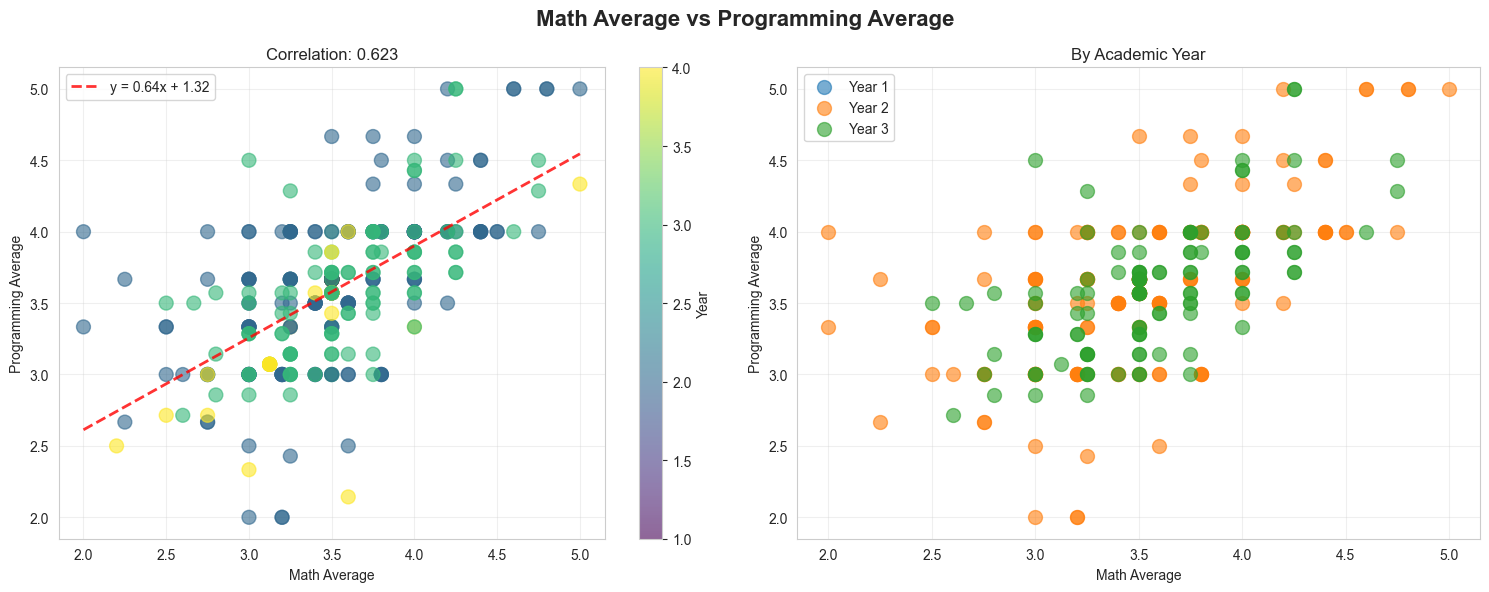


INSIGHTS:
✓ MODERATE positive correlation - Math skills somewhat relate to programming skills


In [ ]:
# ============================================================================
# Math Average vs Programming Average (Numerical vs Numerical)
# ============================================================================

# Prepare data - combine all years with generic column names
data_1y_math_prog = data_1y[['1Y_math_avg', '1Y_programming_avg', 'year_ordinal']].copy()
data_1y_math_prog.columns = ['math_avg', 'programming_avg', 'year']

data_2y_math_prog = data_2y[['2Y_math_avg', '2Y_programming_avg', 'year_ordinal']].copy()
data_2y_math_prog.columns = ['math_avg', 'programming_avg', 'year']

data_3y_math_prog = data_3y[['3Y_math_avg', '3Y_programming_avg', 'year_ordinal']].copy()
data_3y_math_prog.columns = ['math_avg', 'programming_avg', 'year']

# Combine all years
data_math_prog = pd.concat([data_1y_math_prog, data_2y_math_prog, data_3y_math_prog], 
                            ignore_index=True).dropna()

print("=" * 80)
print("MATH AVERAGE VS PROGRAMMING AVERAGE")
print("=" * 80)
print(f"Total students: {len(data_math_prog)}")
print(f"\nMath Average: Mean={data_math_prog['math_avg'].mean():.2f}, Std={data_math_prog['math_avg'].std():.2f}")
print(f"Programming Average: Mean={data_math_prog['programming_avg'].mean():.2f}, Std={data_math_prog['programming_avg'].std():.2f}")

# Calculate correlation
correlation = data_math_prog['math_avg'].corr(data_math_prog['programming_avg'])
print(f"\nPearson Correlation: {correlation:.3f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Math Average vs Programming Average', fontsize=16, fontweight='bold')

# Scatter plot with regression line
axes[0].scatter(data_math_prog['math_avg'], data_math_prog['programming_avg'], 
                alpha=0.6, s=100, c=data_math_prog['year'], cmap='viridis')
axes[0].set_xlabel('Math Average')
axes[0].set_ylabel('Programming Average')
axes[0].set_title(f'Correlation: {correlation:.3f}')

# Add regression line
z = np.polyfit(data_math_prog['math_avg'], data_math_prog['programming_avg'], 1)
p = np.poly1d(z)
x_line = np.linspace(data_math_prog['math_avg'].min(), 
                     data_math_prog['math_avg'].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8, 
             label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Color bar for years
cbar = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar.set_label('Year')

# Scatter plot by year
for year in [1, 2, 3]:
    year_data = data_math_prog[data_math_prog['year'] == year]
    axes[1].scatter(year_data['math_avg'], year_data['programming_avg'], 
                    alpha=0.6, s=100, label=f'Year {year}')

axes[1].set_xlabel('Math Average')
axes[1].set_ylabel('Programming Average')
axes[1].set_title('By Academic Year')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical insights
print("\n" + "=" * 80)
print("INSIGHTS:")
print("=" * 80)

if correlation > 0.7:
    print("✓ STRONG positive correlation - Students good at math tend to be good at programming")
elif correlation > 0.4:
    print("✓ MODERATE positive correlation - Math skills somewhat relate to programming skills")
elif correlation > 0.2:
    print("✓ WEAK positive correlation - Slight relationship between math and programming")
else:
    print("✗ Little to no correlation - Math and programming skills are independent")


### d. Self-Evaluation vs Real Performance

SELF-EVALUATION VS ACTUAL PERFORMANCE
Total students: 323

Correlations:
  Self-rated Programming vs Actual Programming: 0.393
  Self-rated Math vs Actual Math: 0.304
  Self-rated CS vs Overall Performance: 0.202


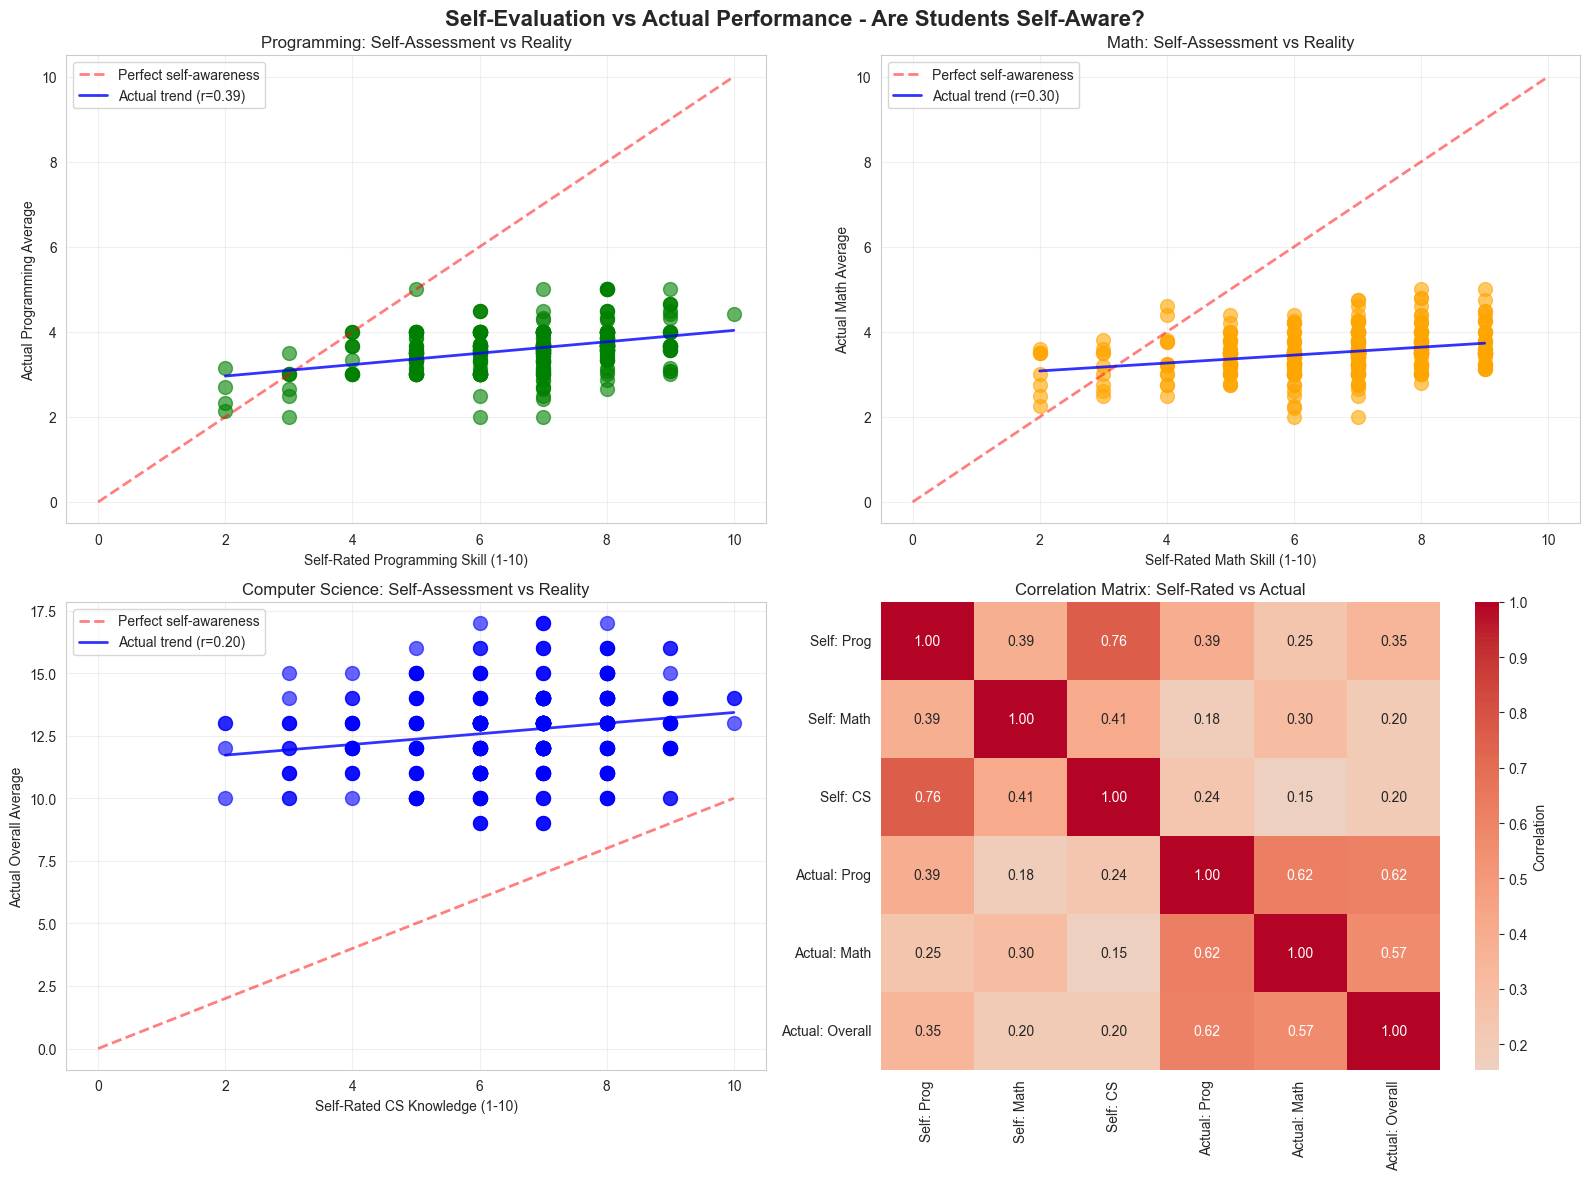


SELF-AWARENESS ANALYSIS:

PROGRAMMING Self-Assessment:
  Overestimate (self-rating > actual by 2+): 238 (73.7%)
  Accurate (within ±2 points): 85 (26.3%)
  Underestimate (self-rating < actual by 2+): 0 (0.0%)

MATH Self-Assessment:
  Overestimate (self-rating > actual by 2+): 249 (77.1%)
  Accurate (within ±2 points): 74 (22.9%)
  Underestimate (self-rating < actual by 2+): 0 (0.0%)

KEY INSIGHTS:
✗ Students have POOR self-awareness in programming skills
✗ Students have POOR self-awareness in math skills
⚠ Students tend to OVERESTIMATE programming skills by 3.1 points on average
⚠ Students tend to OVERESTIMATE math skills by 3.1 points on average


In [ ]:
# ============================================================================
# Self-Rated Skills vs Actual Performance (Numerical vs Numerical)
# ============================================================================

# Prepare data - combine all years with generic column names
# For Year 1
data_1y_self = data_1y[[
    '2 programming', '4 mathematics', '3 computer science',
    '1Y_programming_avg', '1Y_math_avg', '1y average', 'year_ordinal'
]].copy()
data_1y_self.columns = ['self_programming', 'self_math', 'self_cs', 
                        'actual_programming', 'actual_math', 'actual_overall', 'year']

# For Year 2
data_2y_self = data_2y[[
    '2 programming', '4 mathematics', '3 computer science',
    '2Y_programming_avg', '2Y_math_avg', '2y average', 'year_ordinal'
]].copy()
data_2y_self.columns = ['self_programming', 'self_math', 'self_cs', 
                        'actual_programming', 'actual_math', 'actual_overall', 'year']

# For Year 3
data_3y_self = data_3y[[
    '2 programming', '4 mathematics', '3 computer science',
    '3Y_programming_avg', '3Y_math_avg', '3y average', 'year_ordinal'
]].copy()
data_3y_self.columns = ['self_programming', 'self_math', 'self_cs', 
                        'actual_programming', 'actual_math', 'actual_overall', 'year']

# Combine all years
data_self_eval = pd.concat([data_1y_self, data_2y_self, data_3y_self], 
                           ignore_index=True).dropna()

print("=" * 80)
print("SELF-EVALUATION VS ACTUAL PERFORMANCE")
print("=" * 80)
print(f"Total students: {len(data_self_eval)}")

# Calculate correlations
corr_prog = data_self_eval['self_programming'].corr(data_self_eval['actual_programming'])
corr_math = data_self_eval['self_math'].corr(data_self_eval['actual_math'])
corr_cs = data_self_eval['self_cs'].corr(data_self_eval['actual_overall'])

print(f"\nCorrelations:")
print(f"  Self-rated Programming vs Actual Programming: {corr_prog:.3f}")
print(f"  Self-rated Math vs Actual Math: {corr_math:.3f}")
print(f"  Self-rated CS vs Overall Performance: {corr_cs:.3f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Self-Evaluation vs Actual Performance - Are Students Self-Aware?', 
             fontsize=16, fontweight='bold')

# 1. Programming self-rating vs actual
axes[0, 0].scatter(data_self_eval['self_programming'], 
                   data_self_eval['actual_programming'], 
                   alpha=0.6, s=100, color='green')
axes[0, 0].plot([0, 10], [0, 10], 'r--', linewidth=2, alpha=0.5, 
                label='Perfect self-awareness')
z = np.polyfit(data_self_eval['self_programming'], 
               data_self_eval['actual_programming'], 1)
p = np.poly1d(z)
x_line = np.linspace(data_self_eval['self_programming'].min(), 
                     data_self_eval['self_programming'].max(), 100)
axes[0, 0].plot(x_line, p(x_line), "b-", linewidth=2, alpha=0.8, 
                label=f'Actual trend (r={corr_prog:.2f})')
axes[0, 0].set_xlabel('Self-Rated Programming Skill (1-10)')
axes[0, 0].set_ylabel('Actual Programming Average')
axes[0, 0].set_title('Programming: Self-Assessment vs Reality')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Math self-rating vs actual
axes[0, 1].scatter(data_self_eval['self_math'], 
                   data_self_eval['actual_math'], 
                   alpha=0.6, s=100, color='orange')
axes[0, 1].plot([0, 10], [0, 10], 'r--', linewidth=2, alpha=0.5, 
                label='Perfect self-awareness')
z = np.polyfit(data_self_eval['self_math'], 
               data_self_eval['actual_math'], 1)
p = np.poly1d(z)
x_line = np.linspace(data_self_eval['self_math'].min(), 
                     data_self_eval['self_math'].max(), 100)
axes[0, 1].plot(x_line, p(x_line), "b-", linewidth=2, alpha=0.8, 
                label=f'Actual trend (r={corr_math:.2f})')
axes[0, 1].set_xlabel('Self-Rated Math Skill (1-10)')
axes[0, 1].set_ylabel('Actual Math Average')
axes[0, 1].set_title('Math: Self-Assessment vs Reality')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. CS self-rating vs overall performance
axes[1, 0].scatter(data_self_eval['self_cs'], 
                   data_self_eval['actual_overall'], 
                   alpha=0.6, s=100, color='blue')
axes[1, 0].plot([0, 10], [0, 10], 'r--', linewidth=2, alpha=0.5, 
                label='Perfect self-awareness')
z = np.polyfit(data_self_eval['self_cs'], 
               data_self_eval['actual_overall'], 1)
p = np.poly1d(z)
x_line = np.linspace(data_self_eval['self_cs'].min(), 
                     data_self_eval['self_cs'].max(), 100)
axes[1, 0].plot(x_line, p(x_line), "b-", linewidth=2, alpha=0.8, 
                label=f'Actual trend (r={corr_cs:.2f})')
axes[1, 0].set_xlabel('Self-Rated CS Knowledge (1-10)')
axes[1, 0].set_ylabel('Actual Overall Average')
axes[1, 0].set_title('Computer Science: Self-Assessment vs Reality')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Correlation heatmap
corr_matrix = data_self_eval[[
    'self_programming', 'self_math', 'self_cs',
    'actual_programming', 'actual_math', 'actual_overall'
]].corr()

# Rename for better display
corr_matrix.index = ['Self: Prog', 'Self: Math', 'Self: CS', 
                     'Actual: Prog', 'Actual: Math', 'Actual: Overall']
corr_matrix.columns = ['Self: Prog', 'Self: Math', 'Self: CS', 
                       'Actual: Prog', 'Actual: Math', 'Actual: Overall']

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Correlation Matrix: Self-Rated vs Actual')

plt.tight_layout()
plt.show()

# Detailed Analysis
print("\n" + "=" * 80)
print("SELF-AWARENESS ANALYSIS:")
print("=" * 80)

# Calculate accuracy categories
data_self_eval['prog_diff'] = data_self_eval['self_programming'] - data_self_eval['actual_programming']
data_self_eval['math_diff'] = data_self_eval['self_math'] - data_self_eval['actual_math']

overestimate_prog = len(data_self_eval[data_self_eval['prog_diff'] > 2])
accurate_prog = len(data_self_eval[abs(data_self_eval['prog_diff']) <= 2])
underestimate_prog = len(data_self_eval[data_self_eval['prog_diff'] < -2])

overestimate_math = len(data_self_eval[data_self_eval['math_diff'] > 2])
accurate_math = len(data_self_eval[abs(data_self_eval['math_diff']) <= 2])
underestimate_math = len(data_self_eval[data_self_eval['math_diff'] < -2])

print("\nPROGRAMMING Self-Assessment:")
print(f"  Overestimate (self-rating > actual by 2+): {overestimate_prog} ({overestimate_prog/len(data_self_eval)*100:.1f}%)")
print(f"  Accurate (within ±2 points): {accurate_prog} ({accurate_prog/len(data_self_eval)*100:.1f}%)")
print(f"  Underestimate (self-rating < actual by 2+): {underestimate_prog} ({underestimate_prog/len(data_self_eval)*100:.1f}%)")

print("\nMATH Self-Assessment:")
print(f"  Overestimate (self-rating > actual by 2+): {overestimate_math} ({overestimate_math/len(data_self_eval)*100:.1f}%)")
print(f"  Accurate (within ±2 points): {accurate_math} ({accurate_math/len(data_self_eval)*100:.1f}%)")
print(f"  Underestimate (self-rating < actual by 2+): {underestimate_math} ({underestimate_math/len(data_self_eval)*100:.1f}%)")

print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)

if corr_prog > 0.5:
    print("✓ Students have GOOD self-awareness in programming skills")
else:
    print("✗ Students have POOR self-awareness in programming skills")

if corr_math > 0.5:
    print("✓ Students have GOOD self-awareness in math skills")
else:
    print("✗ Students have POOR self-awareness in math skills")

avg_prog_diff = data_self_eval['prog_diff'].mean()
avg_math_diff = data_self_eval['math_diff'].mean()

if avg_prog_diff > 1:
    print(f"⚠ Students tend to OVERESTIMATE programming skills by {avg_prog_diff:.1f} points on average")
elif avg_prog_diff < -1:
    print(f"⚠ Students tend to UNDERESTIMATE programming skills by {abs(avg_prog_diff):.1f} points on average")
else:
    print("✓ Students are generally accurate in programming self-assessment")

if avg_math_diff > 1:
    print(f"⚠ Students tend to OVERESTIMATE math skills by {avg_math_diff:.1f} points on average")
elif avg_math_diff < -1:
    print(f"⚠ Students tend to UNDERESTIMATE math skills by {abs(avg_math_diff):.1f} points on average")
else:
    print("✓ Students are generally accurate in math self-assessment")

# 1) Numerical-Numerical Data relationships 

In [ ]:
# Prepare combined data for all years
data_1y_cat = data_1y.copy()
data_1y_cat['overall_avg'] = data_1y_cat['1y average']
data_1y_cat['year'] = 1

data_2y_cat = data_2y.copy()
data_2y_cat['overall_avg'] = data_2y_cat['2y average']
data_2y_cat['year'] = 2

data_3y_cat = data_3y.copy()
data_3y_cat['overall_avg'] = data_3y_cat['3y average']
data_3y_cat['year'] = 3

# Combine all years
data_combined = pd.concat([data_1y_cat, data_2y_cat, data_3y_cat], ignore_index=True)




ANALYSIS 1: PERFORMANCE vs STUDY PREFERENCE


C:\Users\HP\AppData\Local\Temp\ipykernel_17684\476469766.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_combined, x='you prefer to study', y='overall_avg',
C:\Users\HP\AppData\Local\Temp\ipykernel_17684\476469766.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_combined, x='you prefer to study', y='overall_avg',
c:\Users\HP\anaconda3old\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\HP\anaconda3old\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.3% of the points cannot be placed; you m

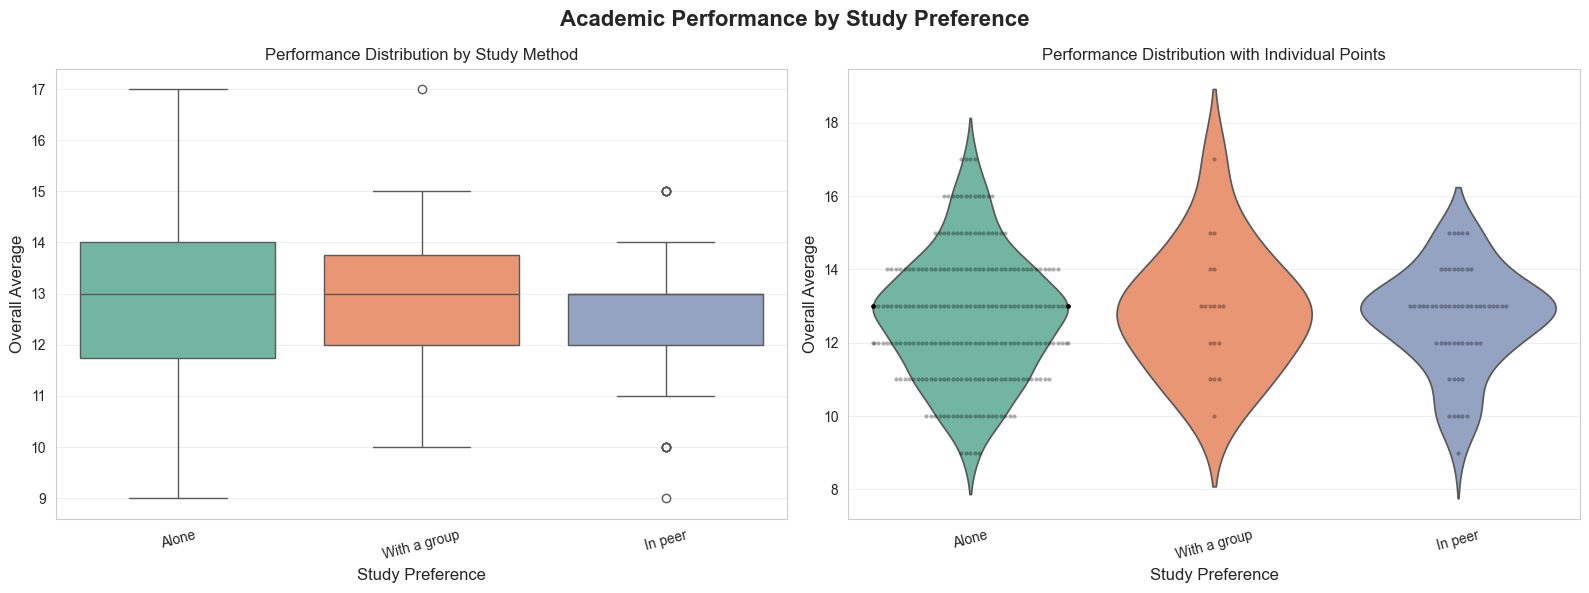


Statistics by Study Preference:
                     count   mean   std   min   max
you prefer to study                                
Alone                  248  12.69  1.70   9.0  17.0
In peer                 57  12.65  1.40   9.0  15.0
With a group            18  12.89  1.71  10.0  17.0

ANOVA Test: F-statistic = 0.146, p-value = 0.8646
✗ No statistically significant difference between groups


In [ ]:

# ============================================================================
# ANALYSIS 1: Performance vs Study Preference (Alone/Group/Peer)
# ============================================================================
print("\n\n" + "=" * 80)
print("ANALYSIS 1: PERFORMANCE vs STUDY PREFERENCE")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Academic Performance by Study Preference', fontsize=16, fontweight='bold')

# Box plot
sns.boxplot(data=data_combined, x='you prefer to study', y='overall_avg', 
            palette='Set2', ax=axes[0])
axes[0].set_xlabel('Study Preference', fontsize=12)
axes[0].set_ylabel('Overall Average', fontsize=12)
axes[0].set_title('Performance Distribution by Study Method')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

# Violin plot with swarm
sns.violinplot(data=data_combined, x='you prefer to study', y='overall_avg', 
               palette='Set2', ax=axes[1], inner=None)
sns.swarmplot(data=data_combined, x='you prefer to study', y='overall_avg', 
              color='black', alpha=0.3, size=3, ax=axes[1])
axes[1].set_xlabel('Study Preference', fontsize=12)
axes[1].set_ylabel('Overall Average', fontsize=12)
axes[1].set_title('Performance Distribution with Individual Points')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical summary
study_pref_stats = data_combined.groupby('you prefer to study')['overall_avg'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)
print("\nStatistics by Study Preference:")
print(study_pref_stats)

# ANOVA test
from scipy.stats import f_oneway
groups = [group['overall_avg'].values for name, group in data_combined.groupby('you prefer to study')]
f_stat, p_value = f_oneway(*groups)
print(f"\nANOVA Test: F-statistic = {f_stat:.3f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("✓ Statistically significant difference between groups")
else:
    print("✗ No statistically significant difference between groups")




ANALYSIS 2: PERFORMANCE vs BAC SPECIALTY


C:\Users\HP\AppData\Local\Temp\ipykernel_17684\3940690021.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_combined, x='what was your bac specialty', y='overall_avg',
C:\Users\HP\AppData\Local\Temp\ipykernel_17684\3940690021.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_combined, x='what was your bac specialty', palette='Set3', ax=ax2)


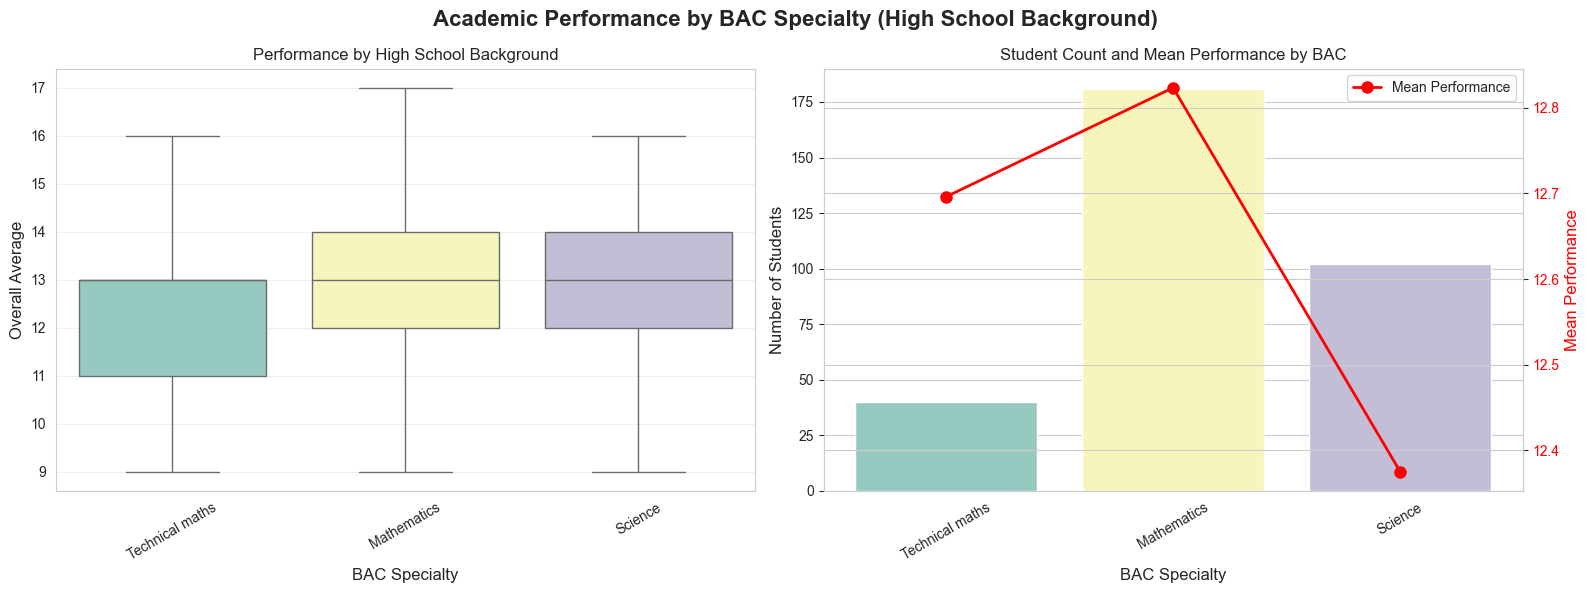


Statistics by BAC Specialty:
                             count   mean   std  min   max
what was your bac specialty                               
Mathematics                    181  12.70  1.69  9.0  17.0
Science                        102  12.82  1.53  9.0  16.0
Technical maths                 40  12.38  1.73  9.0  16.0

ANOVA Test: F-statistic = 1.062, p-value = 0.3468
✗ No statistically significant difference between BAC specialties


In [ ]:

# ============================================================================
# ANALYSIS 2: Performance vs BAC Specialty
# ============================================================================
print("\n\n" + "=" * 80)
print("ANALYSIS 2: PERFORMANCE vs BAC SPECIALTY")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Academic Performance by BAC Specialty (High School Background)', 
             fontsize=16, fontweight='bold')

# Box plot
sns.boxplot(data=data_combined, x='what was your bac specialty', y='overall_avg', 
            palette='Set3', ax=axes[0])
axes[0].set_xlabel('BAC Specialty', fontsize=12)
axes[0].set_ylabel('Overall Average', fontsize=12)
axes[0].set_title('Performance by High School Background')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3, axis='y')

# Count plot with mean overlay
bac_stats = data_combined.groupby('what was your bac specialty')['overall_avg'].agg(['mean', 'count'])
ax2 = axes[1]
sns.countplot(data=data_combined, x='what was your bac specialty', palette='Set3', ax=ax2)
ax2.set_xlabel('BAC Specialty', fontsize=12)
ax2.set_ylabel('Number of Students', fontsize=12)
ax2.tick_params(axis='x', rotation=30)

# Add mean performance as line on secondary axis
ax2_twin = ax2.twinx()
ax2_twin.plot(range(len(bac_stats)), bac_stats['mean'], 'ro-', linewidth=2, 
              markersize=8, label='Mean Performance')
ax2_twin.set_ylabel('Mean Performance', fontsize=12, color='red')
ax2_twin.tick_params(axis='y', labelcolor='red')
ax2_twin.legend(loc='upper right')
ax2.set_title('Student Count and Mean Performance by BAC')

plt.tight_layout()
plt.show()

# Statistical summary
bac_stats_full = data_combined.groupby('what was your bac specialty')['overall_avg'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)
print("\nStatistics by BAC Specialty:")
print(bac_stats_full)

# ANOVA test
groups = [group['overall_avg'].values for name, group in data_combined.groupby('what was your bac specialty')]
f_stat, p_value = f_oneway(*groups)
print(f"\nANOVA Test: F-statistic = {f_stat:.3f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("✓ Statistically significant difference between BAC specialties")
else:
    print("✗ No statistically significant difference between BAC specialties")





ANALYSIS 3: PERFORMANCE vs PLANNER USAGE


C:\Users\HP\AppData\Local\Temp\ipykernel_17684\1330340120.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_combined,
C:\Users\HP\AppData\Local\Temp\ipykernel_17684\1330340120.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_combined,


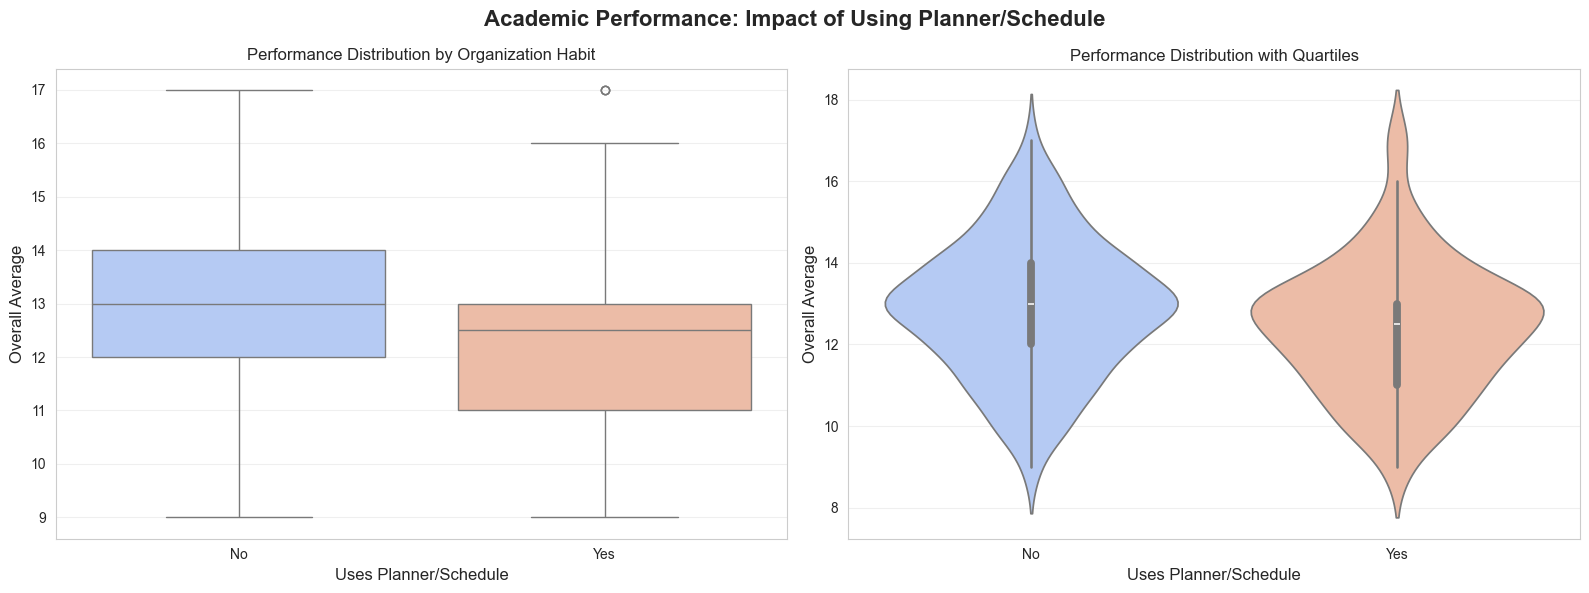


Statistics by Planner Usage:
                                                    count   mean   std  min  \
do you use a planer or a schedule in your revis...                            
No                                                    201  12.88  1.64  9.0   
Yes                                                   122  12.39  1.62  9.0   

                                                     max  
do you use a planer or a schedule in your revis...        
No                                                  17.0  
Yes                                                 17.0  

T-Test: t-statistic = -2.596, p-value = 0.0099
✗ Students who use planners perform 0.49 points WORSE (statistically significant)


In [ ]:

# ============================================================================
# ANALYSIS 3: Performance vs Planner Usage
# ============================================================================
print("\n\n" + "=" * 80)
print("ANALYSIS 3: PERFORMANCE vs PLANNER USAGE")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Academic Performance: Impact of Using Planner/Schedule', 
             fontsize=16, fontweight='bold')

# Box plot
sns.boxplot(data=data_combined, 
            x='do you use a planer or a schedule in your revisions', 
            y='overall_avg', palette='coolwarm', ax=axes[0])
axes[0].set_xlabel('Uses Planner/Schedule', fontsize=12)
axes[0].set_ylabel('Overall Average', fontsize=12)
axes[0].set_title('Performance Distribution by Organization Habit')
axes[0].grid(True, alpha=0.3, axis='y')

# Violin plot
sns.violinplot(data=data_combined, 
               x='do you use a planer or a schedule in your revisions', 
               y='overall_avg', palette='coolwarm', ax=axes[1], inner='box')
axes[1].set_xlabel('Uses Planner/Schedule', fontsize=12)
axes[1].set_ylabel('Overall Average', fontsize=12)
axes[1].set_title('Performance Distribution with Quartiles')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical summary
planner_stats = data_combined.groupby('do you use a planer or a schedule in your revisions')['overall_avg'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)
print("\nStatistics by Planner Usage:")
print(planner_stats)

# T-test
from scipy.stats import ttest_ind
yes_group = data_combined[data_combined['do you use a planer or a schedule in your revisions'] == 'Yes']['overall_avg']
no_group = data_combined[data_combined['do you use a planer or a schedule in your revisions'] == 'No']['overall_avg']
t_stat, p_value = ttest_ind(yes_group, no_group, nan_policy='omit')
print(f"\nT-Test: t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")

mean_diff = yes_group.mean() - no_group.mean()
if p_value < 0.05:
    if mean_diff > 0:
        print(f"✓ Students who use planners perform {abs(mean_diff):.2f} points BETTER (statistically significant)")
    else:
        print(f"✗ Students who use planners perform {abs(mean_diff):.2f} points WORSE (statistically significant)")
else:
    print(f"✗ No statistically significant difference (mean diff: {mean_diff:.2f})")




ANALYSIS 4: PERFORMANCE vs GENDER


C:\Users\HP\AppData\Local\Temp\ipykernel_17684\2424950546.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_combined, x='what is your gender', y='overall_avg',
C:\Users\HP\AppData\Local\Temp\ipykernel_17684\2424950546.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data_combined, x='what is your gender', y='overall_avg',


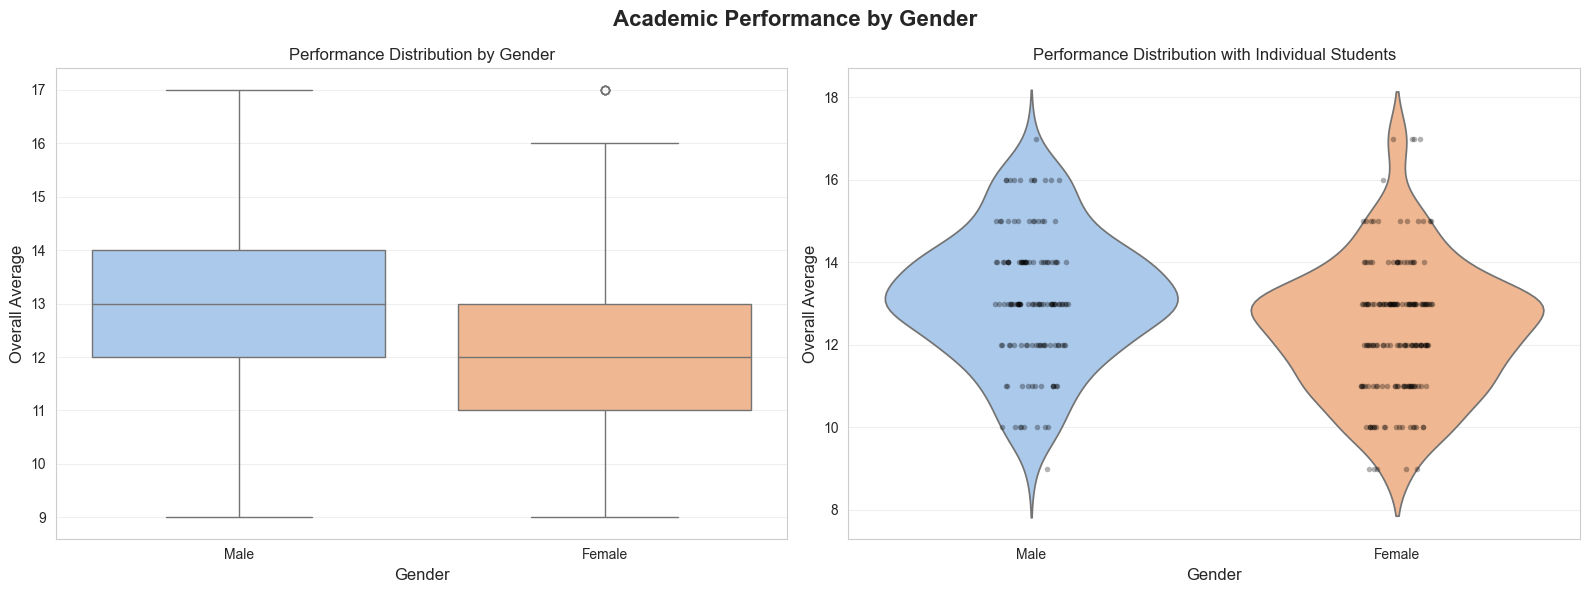


Statistics by Gender:
                     count   mean   std  min   max
what is your gender                               
Female                 182  12.36  1.62  9.0  17.0
Male                   141  13.13  1.59  9.0  17.0

T-Test: t-statistic = 4.315, p-value = 0.0000
✓ Male students perform 0.78 points BETTER (statistically significant)


In [ ]:

# ============================================================================
# ANALYSIS 4: Performance vs Gender
# ============================================================================
print("\n\n" + "=" * 80)
print("ANALYSIS 4: PERFORMANCE vs GENDER")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Academic Performance by Gender', fontsize=16, fontweight='bold')

# Box plot
sns.boxplot(data=data_combined, x='what is your gender', y='overall_avg', 
            palette='pastel', ax=axes[0])
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Overall Average', fontsize=12)
axes[0].set_title('Performance Distribution by Gender')
axes[0].grid(True, alpha=0.3, axis='y')

# Violin plot with individual points
sns.violinplot(data=data_combined, x='what is your gender', y='overall_avg', 
               palette='pastel', ax=axes[1], inner=None)
sns.stripplot(data=data_combined, x='what is your gender', y='overall_avg', 
              color='black', alpha=0.3, size=4, ax=axes[1])
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Overall Average', fontsize=12)
axes[1].set_title('Performance Distribution with Individual Students')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical summary
gender_stats = data_combined.groupby('what is your gender')['overall_avg'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)
print("\nStatistics by Gender:")
print(gender_stats)

# T-test
male_group = data_combined[data_combined['what is your gender'] == 'Male']['overall_avg']
female_group = data_combined[data_combined['what is your gender'] == 'Female']['overall_avg']
t_stat, p_value = ttest_ind(male_group, female_group, nan_policy='omit')
print(f"\nT-Test: t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")

mean_diff = male_group.mean() - female_group.mean()
if p_value < 0.05:
    if mean_diff > 0:
        print(f"✓ Male students perform {abs(mean_diff):.2f} points BETTER (statistically significant)")
    else:
        print(f"✓ Female students perform {abs(mean_diff):.2f} points BETTER (statistically significant)")
else:
    print(f"✗ No statistically significant gender difference (mean diff: {mean_diff:.2f})")



In [ ]:

# ============================================================================
# SUMMARY COMPARISON
# ============================================================================
print("\n\n" + "=" * 80)
print("SUMMARY: WHICH FACTORS MATTER MOST?")
print("=" * 80)

summary_data = {
    'Factor': ['Study Preference', 'BAC Specialty', 'Planner Usage', 'Gender'],
    'Effect_Size': [
        study_pref_stats['mean'].max() - study_pref_stats['mean'].min(),
        bac_stats_full['mean'].max() - bac_stats_full['mean'].min(),
        abs(yes_group.mean() - no_group.mean()),
        abs(male_group.mean() - female_group.mean())
    ]
}
summary_df = pd.DataFrame(summary_data).sort_values('Effect_Size', ascending=False)
print("\nRanking by Effect Size (performance difference):")
print(summary_df.to_string(index=False))



SUMMARY: WHICH FACTORS MATTER MOST?

Ranking by Effect Size (performance difference):
          Factor  Effect_Size
          Gender     0.777609
   Planner Usage     0.487154
   BAC Specialty     0.440000
Study Preference     0.240000


# 3) Categorical-Categorical Data relationships 

In [ ]:

# Prepare combined data
data_1y_catcat = data_1y.copy()
data_1y_catcat['year'] = 1

data_2y_catcat = data_2y.copy()
data_2y_catcat['year'] = 2

data_3y_catcat = data_3y.copy()
data_3y_catcat['year'] = 3

# Combine all years
data_catcat = pd.concat([data_1y_catcat, data_2y_catcat, data_3y_catcat], ignore_index=True)

print("=" * 80)
print("CATEGORICAL vs CATEGORICAL BIVARIATE ANALYSES")
print("=" * 80)
print(f"Total students across all years: {len(data_catcat)}")


CATEGORICAL vs CATEGORICAL BIVARIATE ANALYSES
Total students across all years: 323




ANALYSIS 1: GENDER vs STUDY PREFERENCE

Contingency Table (Count):
you prefer to study  Alone  In peer  With a group  Total
what is your gender                                     
Female                 142       29            11    182
Male                   106       28             7    141
Total                  248       57            18    323

Percentage by Gender (%):
you prefer to study  Alone  In peer  With a group
what is your gender                              
Female               78.02    15.93          6.04
Male                 75.18    19.86          4.96


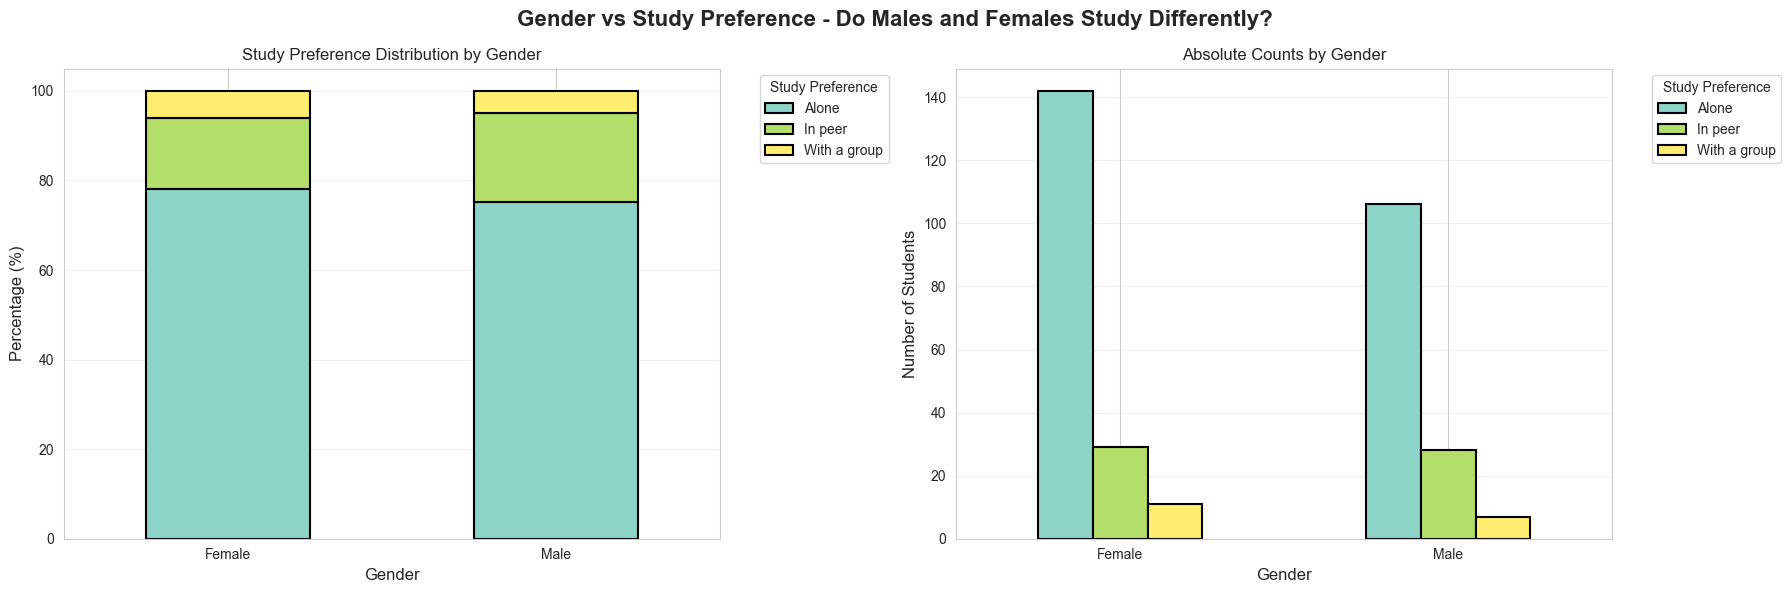


Chi-Square Test:
  χ² = 0.943, df = 2, p-value = 0.6240
  ✗ No statistically significant association (p ≥ 0.05)
  → Gender and study preference are INDEPENDENT


In [ ]:

# ============================================================================
# ANALYSIS 1: Gender vs Study Preference
# ============================================================================
print("\n\n" + "=" * 80)
print("ANALYSIS 1: GENDER vs STUDY PREFERENCE")
print("=" * 80)

# Create contingency table
gender_study_ct = pd.crosstab(data_catcat['what is your gender'], 
                               data_catcat['you prefer to study'], 
                               margins=True, margins_name='Total')
print("\nContingency Table (Count):")
print(gender_study_ct)

# Percentage table
gender_study_pct = pd.crosstab(data_catcat['what is your gender'], 
                                data_catcat['you prefer to study'], 
                                normalize='index') * 100
print("\nPercentage by Gender (%):")
print(gender_study_pct.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Gender vs Study Preference - Do Males and Females Study Differently?', 
             fontsize=16, fontweight='bold')

# Stacked bar chart
gender_study_pct.plot(kind='bar', stacked=True, ax=axes[0], 
                      colormap='Set3', edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].set_title('Study Preference Distribution by Gender')
axes[0].legend(title='Study Preference', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Grouped bar chart
gender_study_ct_no_total = pd.crosstab(data_catcat['what is your gender'], 
                                        data_catcat['you prefer to study'])
gender_study_ct_no_total.plot(kind='bar', ax=axes[1], colormap='Set3', 
                              edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Number of Students', fontsize=12)
axes[1].set_title('Absolute Counts by Gender')
axes[1].legend(title='Study Preference', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Chi-square test
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(gender_study_ct_no_total)
print(f"\nChi-Square Test:")
print(f"  χ² = {chi2:.3f}, df = {dof}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("  ✓ Statistically significant association (p < 0.05)")
    print("  → Gender and study preference are RELATED")
else:
    print("  ✗ No statistically significant association (p ≥ 0.05)")
    print("  → Gender and study preference are INDEPENDENT")




ANALYSIS 4: STUDY LOCATION vs STUDY PREFERENCE

Contingency Table (Count):
you prefer to study           Alone  In peer  With a group  Total
where do you prefer to study                                     
At home                          38       13             1     52
In the dorms' library             2        1             1      4
In the school's library          59       20             9     88
In your room (dorms)            149       23             7    179
Total                           248       57            18    323

Percentage by Study Location (%):
you prefer to study           Alone  In peer  With a group
where do you prefer to study                              
At home                       73.08    25.00          1.92
In the dorms' library         50.00    25.00         25.00
In the school's library       67.05    22.73         10.23
In your room (dorms)          83.24    12.85          3.91


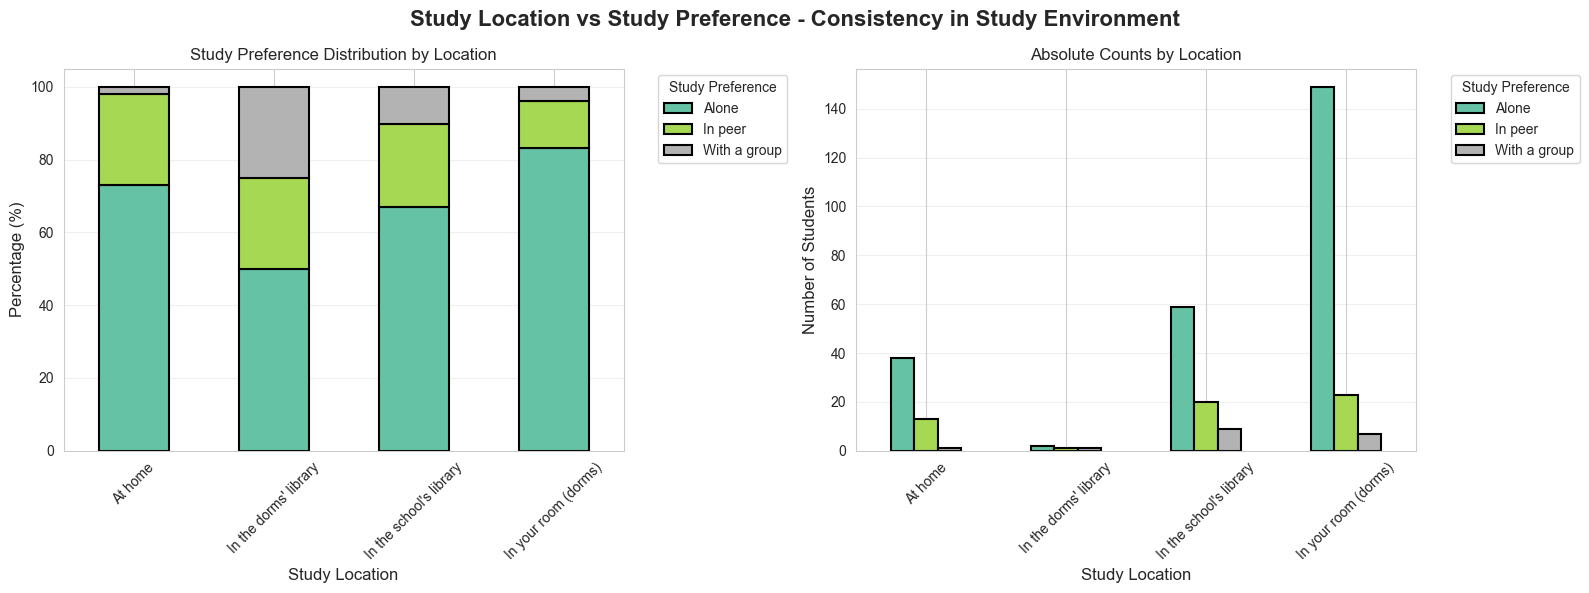


Chi-Square Test:
  χ² = 16.124, df = 6, p-value = 0.0131
  Cramér's V (effect size): 0.158 (small)
  ✓ Statistically significant association (p < 0.05)
  → Study location and preference are RELATED
  → Students show CONSISTENT patterns in their study environment choices


In [ ]:
# ============================================================================
# ANALYSIS 2: Study Location vs Study Preference
# ============================================================================
print("\n\n" + "=" * 80)
print("ANALYSIS 4: STUDY LOCATION vs STUDY PREFERENCE")
print("=" * 80)

# Create contingency table
location_preference_ct = pd.crosstab(data_catcat['where do you prefer to study'], 
                                     data_catcat['you prefer to study'], 
                                     margins=True, margins_name='Total')
print("\nContingency Table (Count):")
print(location_preference_ct)

# Percentage table
location_preference_pct = pd.crosstab(data_catcat['where do you prefer to study'], 
                                      data_catcat['you prefer to study'], 
                                      normalize='index') * 100
print("\nPercentage by Study Location (%):")
print(location_preference_pct.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Study Location vs Study Preference - Consistency in Study Environment', 
             fontsize=16, fontweight='bold')

# Stacked bar chart
location_preference_pct.plot(kind='bar', stacked=True, ax=axes[0], 
                            colormap='Set2', edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Study Location', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].set_title('Study Preference Distribution by Location')
axes[0].legend(title='Study Preference', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Grouped bar chart
location_preference_ct_no_total = pd.crosstab(data_catcat['where do you prefer to study'], 
                                              data_catcat['you prefer to study'])
location_preference_ct_no_total.plot(kind='bar', ax=axes[1], 
                                    colormap='Set2', edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Study Location', fontsize=12)
axes[1].set_ylabel('Number of Students', fontsize=12)
axes[1].set_title('Absolute Counts by Location')
axes[1].legend(title='Study Preference', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(location_preference_ct_no_total)
print(f"\nChi-Square Test:")
print(f"  χ² = {chi2:.3f}, df = {dof}, p-value = {p_value:.4f}")

# Cramér's V
n = location_preference_ct_no_total.sum().sum()
min_dim = min(location_preference_ct_no_total.shape[0] - 1, 
              location_preference_ct_no_total.shape[1] - 1)
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"  Cramér's V (effect size): {cramers_v:.3f}", end=" ")
if cramers_v < 0.1:
    print("(negligible)")
elif cramers_v < 0.3:
    print("(small)")
elif cramers_v < 0.5:
    print("(medium)")
else:
    print("(large)")

if p_value < 0.05:
    print("  ✓ Statistically significant association (p < 0.05)")
    print("  → Study location and preference are RELATED")
    print("  → Students show CONSISTENT patterns in their study environment choices")
else:
    print("  ✗ No statistically significant association (p ≥ 0.05)")
    print("  → Study location and preference are INDEPENDENT")